# Librerías

In [14]:
import pandas as pd
import networkx as nx
import itertools
from tqdm import tqdm
import seaborn as sns
import textwrap
import os
from matplotlib.colors import LinearSegmentedColormap, rgb2hex
from reglas_grafo import (regla_nivel, regla_categoria, regla_estilo, 
                          regla_adventurous, regla_weather, regla_application)

# Carga de datos

In [16]:
print("Cargando datos...")
df = pd.read_csv("../Datos/Transformados/df_resultado.csv", sep=";")
df_colores_ref = pd.read_csv("../Datos/Transformados/completo_combinaciones_colores.csv")

# Filtrar Temporada 7
df_grafo = df[df["temporada"] == 7].copy().reset_index(drop=True)
print(f"Total de prendas a procesar: {len(df_grafo)}")

Cargando datos...
Total de prendas a procesar: 2031


# Preparación de colores

Definimos los colores que deben combinar con todo. Cargamos el CSV de combinaciones normalizado a MAYÚSCULAS. Y creamos la función de Regla de Color Específica para este Script

In [17]:
COLORES_NEUTROS = {
    '000000', 'FFFFFF', '808080', '000080', '00008B', '153668',
    'BLACK', 'WHITE', 'GREY', 'NAVY', 'BEIGE', 'NUDE', 'BLUE'   
}

colores_validos = set()
for _, row in df_colores_ref.iterrows():
    if row['score'] > 0.4:
        c1 = str(row['color1']).strip().lstrip('#').upper()
        c2 = str(row['color2']).strip().lstrip('#').upper()
        colores_validos.add((c1, c2))
        colores_validos.add((c2, c1))

def regla_color_final(r1, r2):
    c1 = str(r1["hexadecimal"]).strip().lstrip('#').upper()
    c2 = str(r2["hexadecimal"]).strip().lstrip('#').upper()
    
    if c1 in COLORES_NEUTROS or c2 in COLORES_NEUTROS:
        return True

    if c1 == c2:
        return True
        
    return (c1, c2) in colores_validos

# Preparacion de datos

In [18]:
# Solo temporada 7
df_expandido = df[df["temporada"] == 7].copy()

df_expandido.reset_index(drop=True, inplace=True)
features_relevantes = [
    "indice",              
    "id_producto",
    "nombre_producto",
    "hexadecimal",
    "categoria_prenda",
    "subcategoria_prenda",
    "adventurous",
    "weather",
    "style",
    "application",
    "print",
    "basic",
    "nivel",
    "subnivel"
]

missing_cols = [col for col in features_relevantes if col not in df_expandido.columns]
if missing_cols:
    raise ValueError(f"Faltan las siguientes columnas en el CSV: {missing_cols}")

df_grafo = df_expandido[features_relevantes].copy()
print(f"Total de prendas para el grafo: {len(df_grafo)}")

Total de prendas para el grafo: 2031


In [29]:
df_expandido.to_csv("../Datos/Transformados/df_expandido.csv",sep=';',index=False)

In [20]:
df_grafico = df_expandido.drop_duplicates(subset='nombre_producto', keep='first')
df_grafico.shape

(1120, 16)

### Generar la paleta en Seaborn

In [21]:
custom_palette = sns.light_palette("#c66666", n_colors=15, reverse=True)
hex_palette = [rgb2hex(color) for color in custom_palette]
print(hex_palette)

['#c66666', '#c97070', '#cc7a7a', '#cf8383', '#d28e8e', '#d69797', '#d9a1a1', '#dcabab', '#dfb5b5', '#e2bfbf', '#e5c9c9', '#e8d3d3', '#ebdddd', '#eee7e7', '#f2f0f0']


C:\Users\Martin\AppData\Local\Temp\ipykernel_5044\3537379954.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


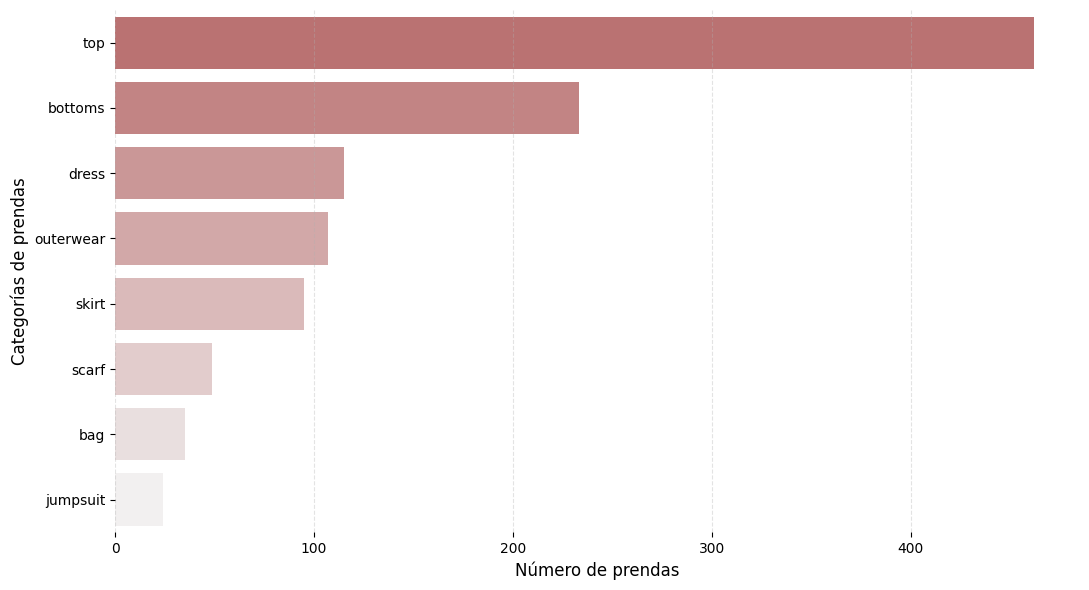

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# --- 1) Mapeo ---
mapeo = {
    "down_part_type": "Pantalones y vaqueros",
    "outside_type": "Chaquetas y abrigos",
    "sweaters": "Jerséis",
    "tops": "Tops y bodies",
    "t-shirts": "Camisetas",
    "skirt_type": "Faldas",
    "cardigan": "Cárdigans",
    "dress_type": "Vestidos",
    "shirt": "Camisas",
    "foulard_type": "Pañuelos y bufandas",
    "blouse": "Blusas",
    "bag_type": "Bolsos",
    "jump_suit_type": "Monos",
    "hoodies": "Sudaderas con capucha",
    "sweatshirt": "Sudaderas sin capucha",
}

# --- 2) Conteos ---
otras = df_grafico[df_grafico["categoria_prenda"] != "top_type"]
conteo_otras = otras["categoria_prenda"].value_counts()

top_data = df_grafico[df_grafico["categoria_prenda"] == "top_type"]
conteo_top = top_data["subcategoria_prenda"].value_counts()

if "top" in conteo_top and "tops" in conteo_top:
    conteo_top["tops"] += conteo_top["top"]
    conteo_top = conteo_top.drop("top")

conteo = (
    pd.concat([conteo_otras, conteo_top])
    .rename(index=mapeo)
    .sort_values(ascending=False)
)

# --- 3) Etiquetas ---
labels = [textwrap.fill(str(label), width=16) for label in conteo.index]

# --- 4) Paleta con saltos ---
base_palette = [
    '#c66666', '#c97070', '#cc7a7a', '#cf8383', '#d28e8e',
    '#d69797', '#d9a1a1', '#dcabab', '#dfb5b5', '#e2bfbf',
    '#e5c9c9', '#e8d3d3', '#ebdddd', '#eee7e7', '#f2f0f0'
]

salto = 2  # <- 2 o 3 normalmente queda bien (3 da más contraste)

# genera índices: 0, 3, 6, 9... y si faltan colores, continúa con 1, 4, 7... luego 2, 5, 8...
idxs = []
for offset in range(salto):
    idxs.extend(list(range(offset, len(base_palette), salto)))

# construye paleta según ese orden y recorta a nº de barras
palette = [base_palette[i] for i in idxs][:len(conteo)]

# --- 5) Gráfico ---
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x=conteo.values,
    y=labels,
    palette=palette
)

ax.set_xlabel("Número de prendas", fontsize=12)
ax.set_ylabel("Categorías de prendas", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.35)
sns.despine(left=True, bottom=True)

ruta_graficos = "../Graficos"
os.makedirs(ruta_graficos, exist_ok=True)
ruta_salida = os.path.join(ruta_graficos, "distribucion_categorias_prendas.png")
plt.savefig(ruta_salida, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


# Reglas del grafo

### **1) Temporada (Regla 1)**

Vamos a utilizar las prendas de la temporada 7 así que no la aplicaremos.

### **2) Nivel (Regla 2)**
- **Condición**:
    - Las prendas de nivel 1 se pueden unir solo con los de nivel 4.
    - Las prendas de nivel 2 con los de nivel 3 o 4.
    - Las prendas de nivel 3 con 2 o 4.
    - Las prendas de nivel 4 con  2, 3 o 4.

    **Teniendo en cuenta**:
#### NIVELES:
Nivel 1 = Cuerpo entero

Nivel 2 = Parte de abajo

Nivel 3 = Parte de arriba

Nivel 4 = Accesorios y abrigos

#### SUBNIVELES
Subnivel 1.1 = Vestido

Subnivel 1.2 = Mono

Subnivel 2.1 = Falda

Subnivel 2.2 = Pantlones

Subnivel 3.1 = Parte de arriba

Subnivel 4.1 = Abrigo

Subnivel 4.2 = Bufanda

Subnivel 4.3 = Bolso

### **3) Categoría de prenda (Regla 3)**
- **Condición**:
Si hay dos prendas del nivel 4, tienen que ser de categoría distinta.

### **4) Colores (Regla 4)**
- **Condición**:
Combinaciones válidas según el color: aquellas que tengan 1 en la columna _choice_ del df _colores_.

### **5) Estilo (Regla 5)**
- **Condición**:
Dos nodos se pueden conectar si comparten al menos un valor en la columna _style_. Por ejemplo:
"classic, street" puede conectarse con "classic, minimal", pero no con "boho".

### **6) Nivel de atrevimiento (Regla 6)**
- **Condición**: Dos nodos se pueden conectar si la diferencia en la columna adventurous es como máximo 1 punto.

### **7) Tiempo (Regla 7)**
- **Condición**:
Dos nodos se pueden conectar si comparten el mismo _weather_. 
    - "warm" y "warm_season" son compatibles.
    - "cold" y "cold_season" son compatibles.
    - "warm/warm_season" y "cold/cold_season" no son compatibles.
    - "all_weather" es compatible con todos.

### **8) Aplicación (Regla 8)**
- **Condición**: Los nodos deben compartir al menos un valor en la columna application para conectarse.


# Creacion del grafo

In [23]:
G = nx.Graph()


features = ["indice", "id_producto", "nombre_producto", "hexadecimal", 
            "categoria_prenda", "nivel", "style", "weather", "adventurous", "application"]

cols_to_use = [c for c in features if c in df_grafo.columns]

for idx, row in df_grafo.iterrows():
    G.add_node(idx, **row[cols_to_use].to_dict())

reglas = [
    lambda r1, r2: regla_nivel(r1["nivel"], r2["nivel"]),
    lambda r1, r2: regla_categoria(r1["categoria_prenda"], r2["categoria_prenda"], r1["nivel"], r2["nivel"]),
    lambda r1, r2: regla_estilo(r1["style"], r2["style"]),
    lambda r1, r2: regla_adventurous(r1["adventurous"], r2["adventurous"]),
    lambda r1, r2: regla_weather(r1["weather"], r2["weather"]),
    lambda r1, r2: regla_application(r1["application"], r2["application"]),
    lambda r1, r2: regla_color_final(r1, r2)
]

print("Generando aristas...")

Generando aristas...


In [24]:
total_comb = len(df_grafo) * (len(df_grafo) - 1) // 2
for idx1, idx2 in tqdm(itertools.combinations(df_grafo.index, 2), total=total_comb):
    row1 = df_grafo.loc[idx1]
    row2 = df_grafo.loc[idx2]

    # Verificar compatibilidad estructural PRIMERO (es la más rápida y descarta más)
    if not regla_nivel(row1["nivel"], row2["nivel"]):
        continue

    # Si pasa nivel, verificamos el resto
    if all(regla(row1, row2) for regla in reglas[1:]): # Saltamos la [0] que ya chequeamos
        G.add_edge(idx1, idx2)
    
print(f"Grafo creado con {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")

100%|██████████| 2061465/2061465 [03:51<00:00, 8901.44it/s] 

Grafo creado con 2031 nodos y 313557 aristas.


# Resultado y guardado del grafo

In [25]:
isolados = list(nx.isolates(G))
print(f"\nResumen del Grafo:")
print(f"- Nodos totales: {G.number_of_nodes()}")
print(f"- Aristas totales: {G.number_of_edges()}")
print(f"- Nodos aislados: {len(isolados)}")

if len(isolados) > 0:
    print("Ejemplo de nodos aislados:", isolados[:5])
else:
    print("No hay nodos aislados.")

# Guardar
nx.write_gml(G, "../Modelos/graph.gml")
df_grafo.to_csv("../Datos/Transformados/df_grafo_final.csv", index=False)
print("Archivos guardados correctamente.")


Resumen del Grafo:
- Nodos totales: 2031
- Aristas totales: 313557
- Nodos aislados: 0
No hay nodos aislados.
Archivos guardados correctamente.


# Visualizacion

Visualizacion: 1602 nodos, 291793 aristas


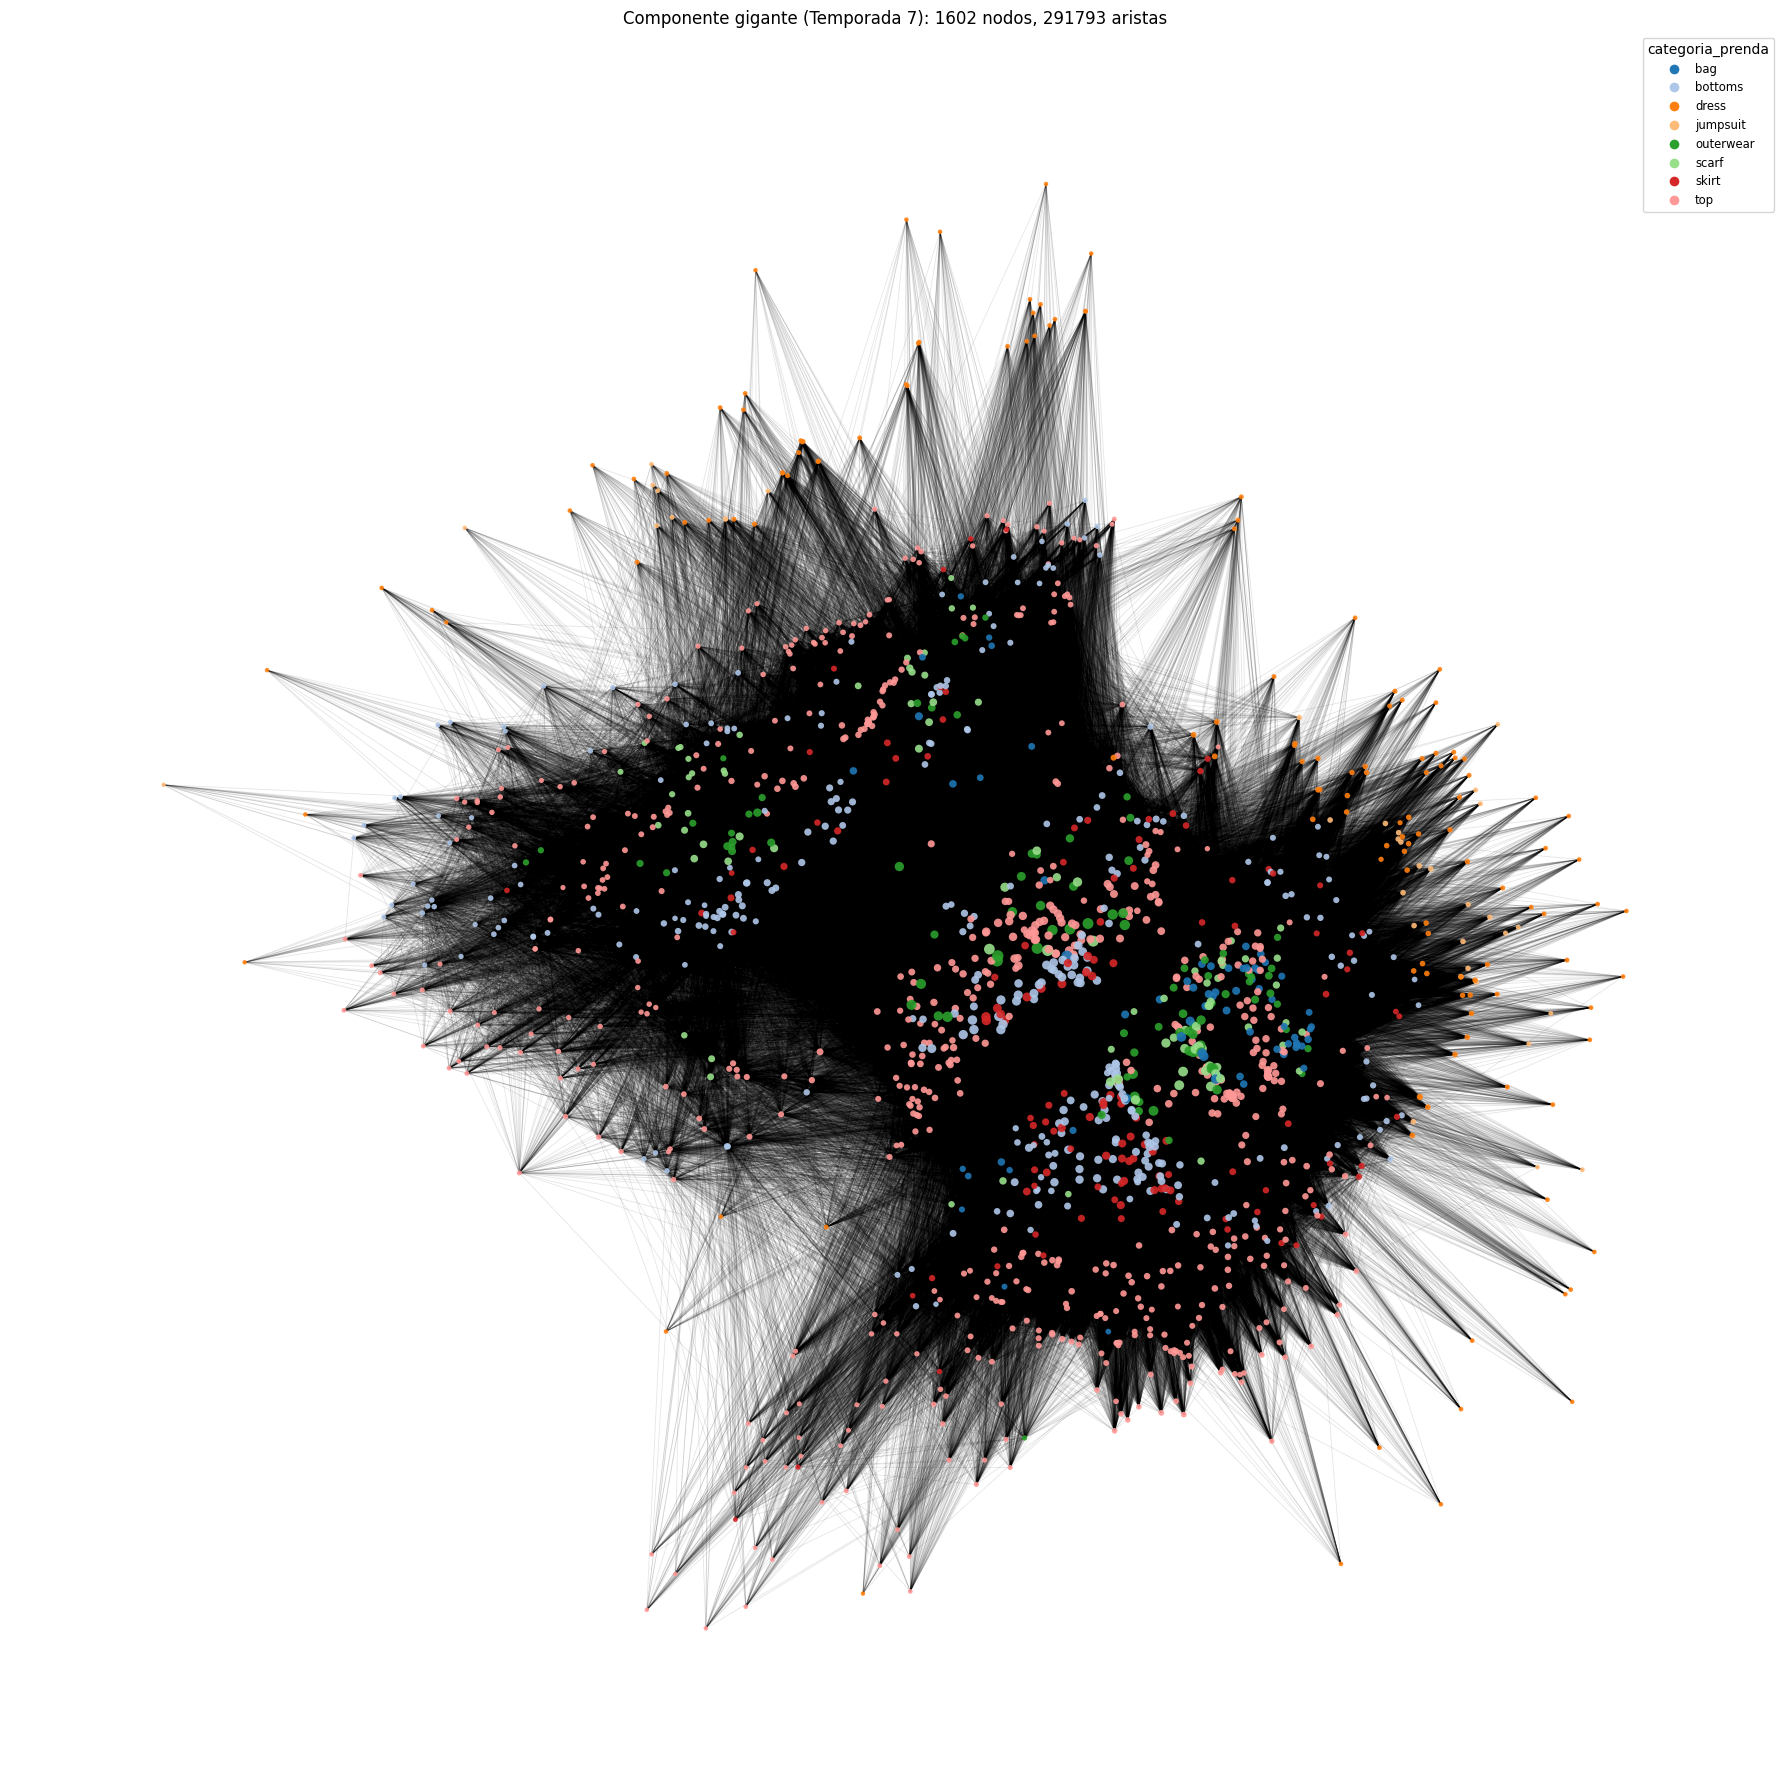

Guardado: grafo_gigante.png


In [26]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import random

# 1) Elegir componente conexa más grande (evita ruido y aislados)
components = list(nx.connected_components(G))
giant = max(components, key=len)
H = G.subgraph(giant).copy()

print("Visualizacion:", H.number_of_nodes(), "nodos,", H.number_of_edges(), "aristas")

# 2) Colores por categoria_prenda (limitando categorías para que no explote la leyenda)
categorias = [H.nodes[n].get("categoria_prenda", "NA") for n in H.nodes()]
cats_unicas = sorted(set(categorias))

# Si hay demasiadas categorías, no hacemos leyenda completa
MAX_LEGEND = 25
use_legend = len(cats_unicas) <= MAX_LEGEND

cmap = plt.get_cmap("tab20")
mapa_colores = {cat: cmap(i % 20) for i, cat in enumerate(cats_unicas)}
node_colors = [mapa_colores[c] for c in categorias]

# 3) Tamaño por grado (mejor lectura)
deg = np.array([H.degree(n) for n in H.nodes()], dtype=float)
# Escala suave para que no haya nodos gigantes
node_sizes = 10 + 60 * (deg - deg.min()) / (deg.max() - deg.min() + 1e-9)

# 4) Layout (spring) - ajusta k si está muy apelotonado
pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(H.number_of_nodes()), iterations=80)

plt.figure(figsize=(18, 18))
nx.draw_networkx_edges(H, pos, alpha=0.10, width=0.6)
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, alpha=0.90, linewidths=0)

plt.title(f"Componente gigante (Temporada 7): {H.number_of_nodes()} nodos, {H.number_of_edges()} aristas")
plt.axis("off")

# Leyenda solo si no hay demasiadas categorías
if use_legend:
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', label=cat,
                   markerfacecolor=mapa_colores[cat], markersize=8)
        for cat in cats_unicas
    ]
    plt.legend(handles=handles, title="categoria_prenda", loc="upper right", fontsize="small")

plt.tight_layout()
plt.show()